In [1]:
#import libraries
import pandas as pd
import numpy as np
import json
from scipy.stats.mstats import winsorize
import seaborn as sns #for scatter plot and box plot
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf #for multiple linear regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf #to fit linear model
from scipy.stats import shapiro # normality test
import statsmodels.api as sm #Q-Q plot
from statsmodels.stats.diagnostic import het_breuschpagan #checking homoskedasticity
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [4]:
#loading data
with open(r"C:\Users\santr\Documents\ML_Project\food_delivery.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert list of dictionaries to DataFrame
df = pd.DataFrame(data)
#print(df.head)
print(df.shape)
print(df.info())

(41953, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          41953 non-null  object 
 3   Delivery_person_Ratings      41953 non-null  object 
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehi

In [5]:
# Remove leading and trailing spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Remove "conditions" prefix from Weatherconditions
df["Weatherconditions"] = (
    df["Weatherconditions"]
    .str.replace("conditions", "", regex=False)
    .str.strip()
)

df["Time_taken(min)"] = pd.to_numeric(
    df["Time_taken(min)"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Convert numeric variables
df["Delivery_person_Age"] = pd.to_numeric(
    df["Delivery_person_Age"], errors="coerce"
).astype("Int64")

df["Delivery_person_Ratings"] = pd.to_numeric(
    df["Delivery_person_Ratings"], errors="coerce"
)

df["multiple_deliveries"] = pd.to_numeric(
    df["multiple_deliveries"], errors="coerce"
).astype("Int64")

df["Time_taken(min)"] = pd.to_numeric(
    df["Time_taken(min)"], errors="coerce"
)

# Convert date
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Convert time variables
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

# Convert categorical variables
cat_cols = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

    
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41953 non-null  object        
 1   Delivery_person_ID           41953 non-null  object        
 2   Delivery_person_Age          40234 non-null  Int64         
 3   Delivery_person_Ratings      40190 non-null  float64       
 4   Restaurant_latitude          41953 non-null  float64       
 5   Restaurant_longitude         41953 non-null  float64       
 6   Delivery_location_latitude   41953 non-null  float64       
 7   Delivery_location_longitude  41953 non-null  float64       
 8   Order_Date                   41953 non-null  datetime64[ns]
 9   Time_Orderd                  40353 non-null  datetime64[ns]
 10  Time_Order_picked            41953 non-null  datetime64[ns]
 11  Weatherconditions            41953 non-nu

# Creating Helping Variables

In [6]:

# Calculate Haversine Distance
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


df["Distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

df["Distance_km"] = df["Distance_km"].round(2)

# Calculate Pickup Waiting Time

df["Pickup_Wait_Time"] = (
    df["Time_Order_picked"] -
    df["Time_Orderd"]
).dt.total_seconds() / 60

# Correct orders crossing midnight
df.loc[
    df["Pickup_Wait_Time"] < 0,
    "Pickup_Wait_Time"
] += 24 * 60


# Create Meal Period

def meal_period(hour):

    if pd.isna(hour):
        return np.nan

    if 6 <= hour < 10:
        return "Breakfast"

    elif 10 <= hour < 15:
        return "Lunch"

    elif 15 <= hour < 18:
        return "Snacks"

    elif 18 <= hour < 23:
        return "Dinner"

    else:
        return "Late Night"

df["Meal_Period"] = df["Time_Orderd"].dt.hour.apply(meal_period)

# Create Peak Hour

def peak_hour(hour):

    if pd.isna(hour):
        return np.nan

    if 7 <= hour < 10:
        return "Morning Peak"

    elif 12 <= hour < 14:
        return "Afternoon Peak"

    elif 17 <= hour < 21:
        return "Evening Peak"

    else:
        return "Non Peak"

df["Peak_Hour"] = df["Time_Orderd"].dt.hour.apply(peak_hour)


# Create Weekend indicator
df["Weekend"] = np.where(
    df["Order_Date"].dt.day_name().isin(["Saturday", "Sunday"]),
    "Yes",
    "No"
)

# Convert engineered categorical variables
new_cat_cols = [
    "Meal_Period",
    "Peak_Hour",
    "Weekend"
   
]

for col in new_cat_cols:
    df[col] = df[col].astype("category")

# Display dataset information

#print(df.shape)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41953 non-null  object        
 1   Delivery_person_ID           41953 non-null  object        
 2   Delivery_person_Age          40234 non-null  Int64         
 3   Delivery_person_Ratings      40190 non-null  float64       
 4   Restaurant_latitude          41953 non-null  float64       
 5   Restaurant_longitude         41953 non-null  float64       
 6   Delivery_location_latitude   41953 non-null  float64       
 7   Delivery_location_longitude  41953 non-null  float64       
 8   Order_Date                   41953 non-null  datetime64[ns]
 9   Time_Orderd                  40353 non-null  datetime64[ns]
 10  Time_Order_picked            41953 non-null  datetime64[ns]
 11  Weatherconditions            41953 non-nu

# Missing Value

In [7]:
cat_cols = [
    "City", "Weatherconditions", "Road_traffic_density", 
    "Festival", "Type_of_order", "Type_of_vehicle"
]
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
            'Distance_km', 'Pickup_Wait_Time', 'Time_taken(min)']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(r'(?i)^nan$', np.nan, regex=True)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.replace(r'(?i)^nan$', np.nan, regex=True)

df.isnull().mean().round(3)*100

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            4.1
Delivery_person_Ratings        4.2
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Order_Date                     0.0
Time_Orderd                    3.8
Time_Order_picked              0.0
Weatherconditions              1.4
Road_traffic_density           1.3
Vehicle_condition              0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
multiple_deliveries            2.2
Festival                       0.5
City                           2.7
Time_taken(min)                0.0
Distance_km                    0.0
Pickup_Wait_Time               3.8
Meal_Period                    3.8
Peak_Hour                      3.8
Weekend                        0.0
dtype: float64

# Missing value replacement

In [8]:
df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
df["Pickup_Wait_Time"] = pd.to_numeric(df["Pickup_Wait_Time"], errors="coerce")

df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())
df["Pickup_Wait_Time"] = df["Pickup_Wait_Time"].fillna(df["Pickup_Wait_Time"].median())

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Weatherconditions"] = df["Weatherconditions"].fillna(df["Weatherconditions"].mode()[0])
df["Road_traffic_density"] = df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0])

df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")

missing = df["Time_Orderd"].isna()

df.loc[missing, "Time_Orderd"] = (
    df.loc[missing, "Time_Order_picked"] - pd.to_timedelta(df.loc[missing, "Pickup_Wait_Time"], unit="m")
)

df["Festival"] = df["Festival"].fillna(df["Festival"].mode()[0])

df["Meal_Period"] = df["Time_Orderd"].dt.hour.apply(meal_period)

df["Peak_Hour"] = df["Time_Orderd"].dt.hour.apply(peak_hour)

print(df.isnull().mean().round(3) * 100)

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            0.0
Delivery_person_Ratings        0.0
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Order_Date                     0.0
Time_Orderd                    0.0
Time_Order_picked              0.0
Weatherconditions              0.0
Road_traffic_density           0.0
Vehicle_condition              0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
multiple_deliveries            0.0
Festival                       0.0
City                           0.0
Time_taken(min)                0.0
Distance_km                    0.0
Pickup_Wait_Time               0.0
Meal_Period                    0.0
Peak_Hour                      0.0
Weekend                        0.0
dtype: float64


In [9]:
df1=df.loc[:,['Delivery_person_Age','Delivery_person_Ratings','Weatherconditions','Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'Distance_km', 'Pickup_Wait_Time', 'Meal_Period', 'Peak_Hour',
       'Weekend']]

In [10]:

def out_zscores(var):
   return ( ((var-var.mean())/var.std()).abs()>3).mean().round()*100
print("z_score")
print(df1[['Delivery_person_Age','Delivery_person_Ratings','Distance_km','Pickup_Wait_Time']].apply(out_zscores))

def out_iqr(var):
    q3=var.quantile(0.75)
    q1=var.quantile(0.25)
    iqr=q3-q1
    ll=q1-(1.5*iqr)
    ul=q3+(1.5*iqr)
    return (((var>ul)|(var<ll)).mean()*100).round(2)
print("iqr")
df1[['Delivery_person_Age','Delivery_person_Ratings','Distance_km','Pickup_Wait_Time']].apply(out_iqr)


z_score
Delivery_person_Age        0.0
Delivery_person_Ratings    0.0
Distance_km                0.0
Pickup_Wait_Time           0.0
dtype: float64
iqr


Delivery_person_Age        0.11
Delivery_person_Ratings    5.52
Distance_km                0.00
Pickup_Wait_Time           0.19
dtype: float64

# Outlier treatment

In [11]:
cols = ['Delivery_person_Ratings',
        'Distance_km',
        'Pickup_Wait_Time']

for col in cols:
    df1[col] = winsorize(df1[col], limits=[0.01, 0.01])
print("iqr")
df1[['Delivery_person_Age','Delivery_person_Ratings','Distance_km','Pickup_Wait_Time']].apply(out_iqr)


iqr


Delivery_person_Age        0.11
Delivery_person_Ratings    5.41
Distance_km                0.00
Pickup_Wait_Time           0.00
dtype: float64

# EDA


<Axes: >

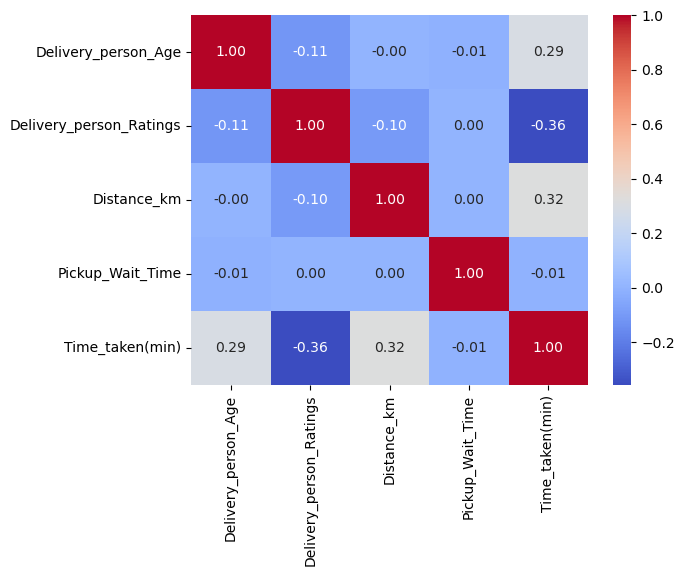

In [12]:
cols = ['Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Pickup_Wait_Time',
        'Time_taken(min)']
sns.heatmap(df1[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")


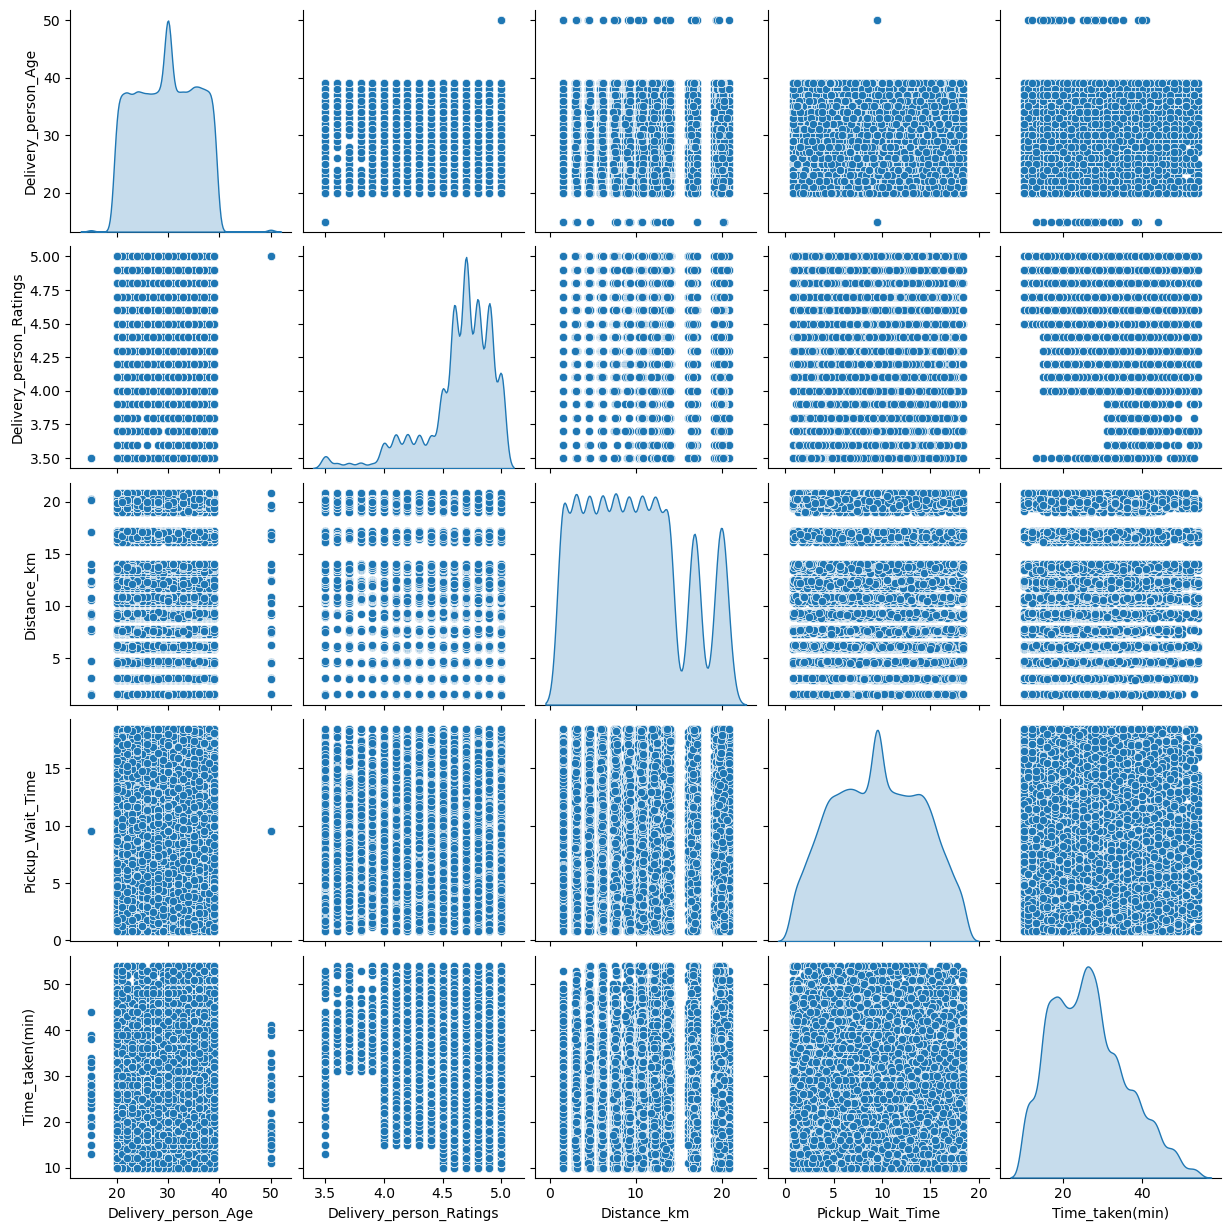

In [13]:

sns.pairplot(
        df1[cols],
    diag_kind='kde')
plt.show()

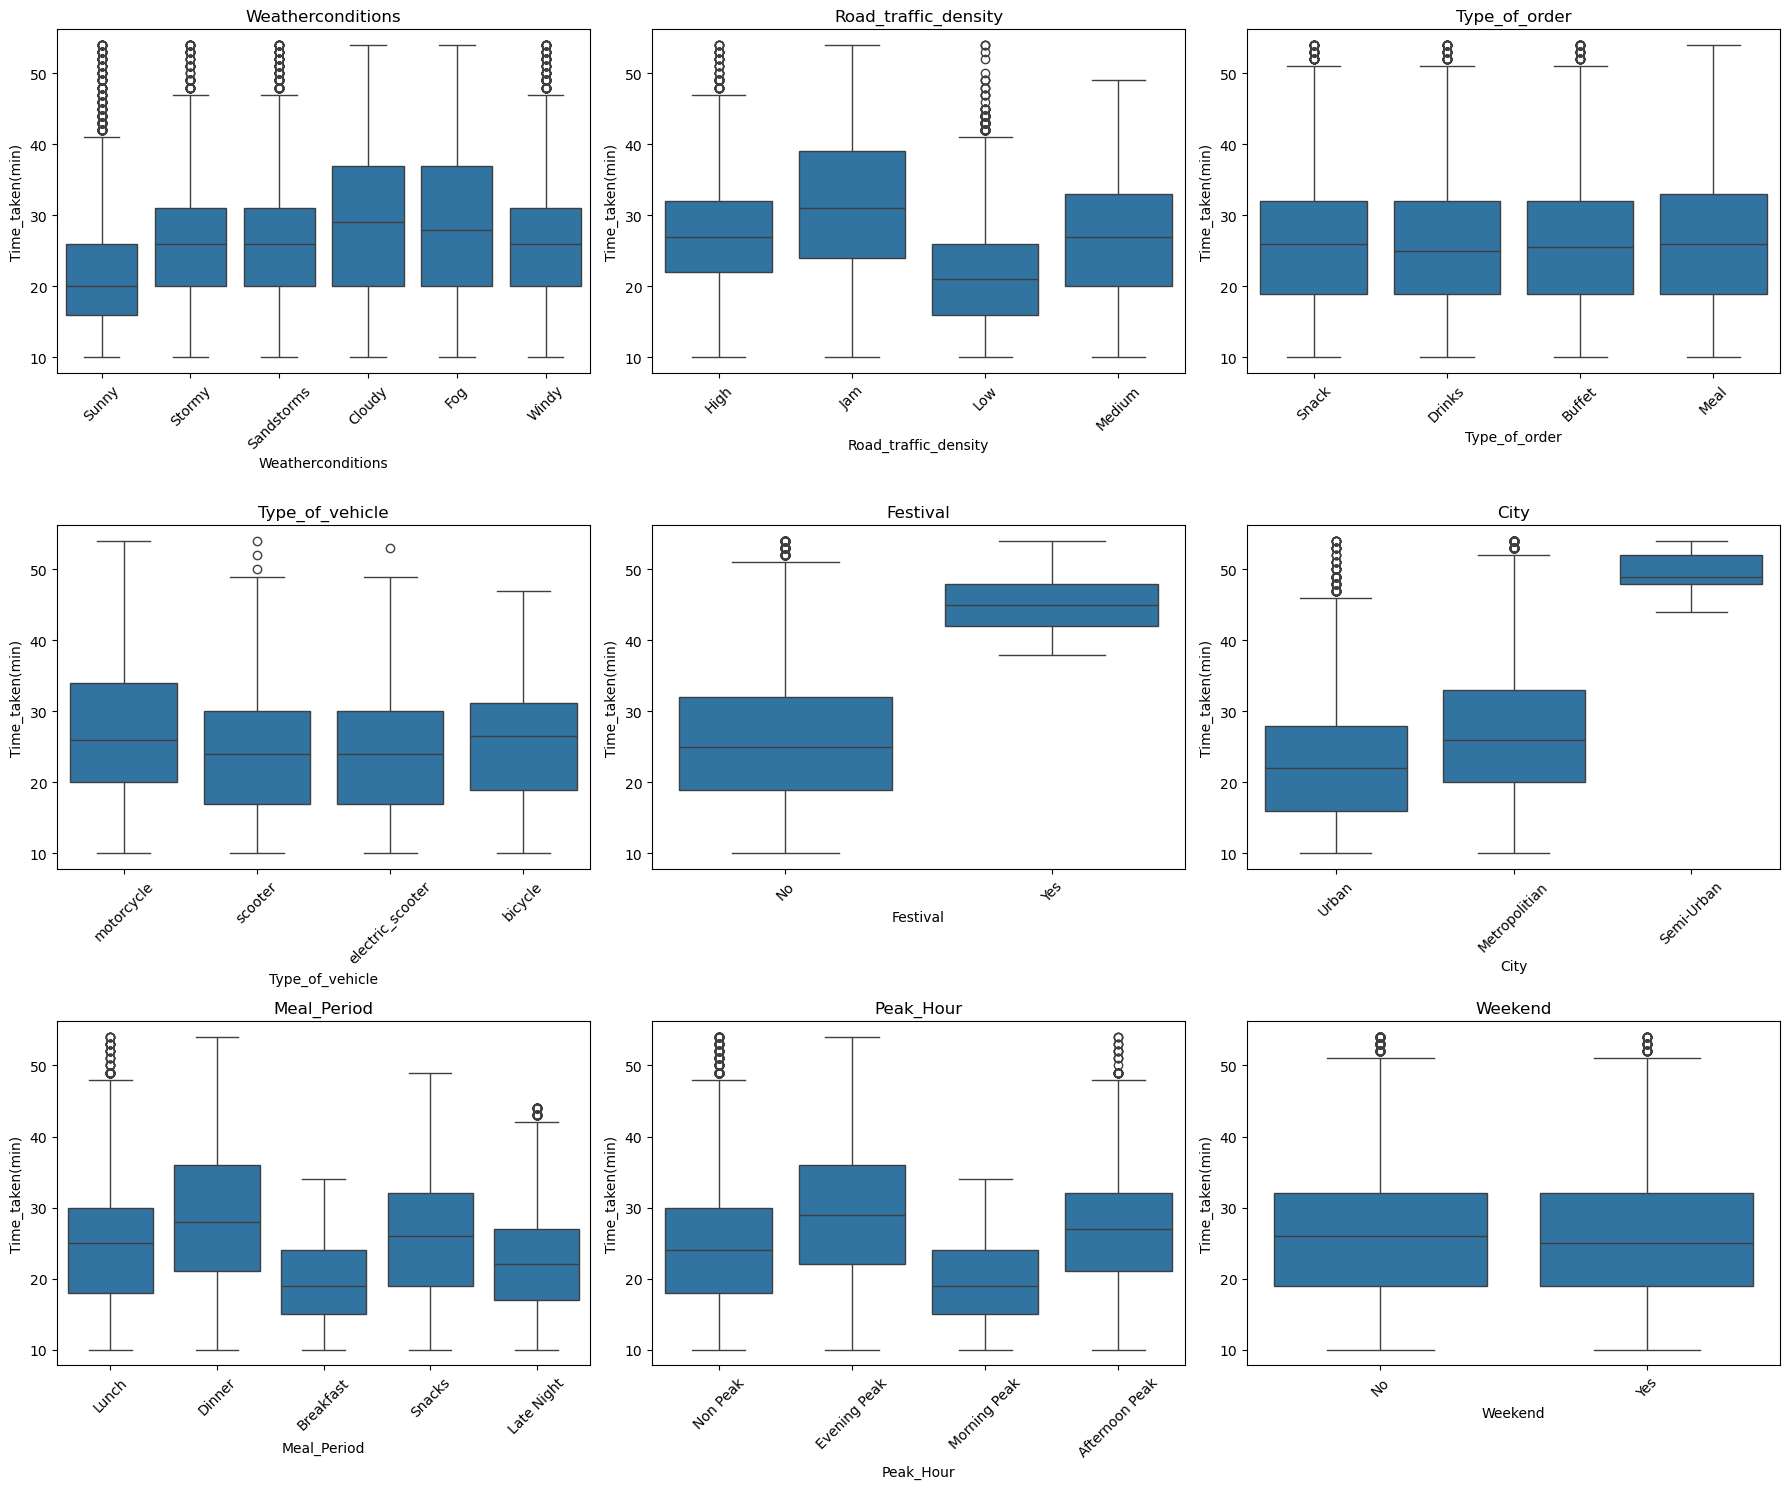

In [14]:
#boxplot

cat_cols = [
    'Weatherconditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City',
    'Meal_Period',
    'Peak_Hour',
    'Weekend'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df1, x=col, y='Time_taken(min)', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Fitting linear model 

In [15]:
df1 = df1.loc[:, ~df1.columns.duplicated()]

num_cols = [
    'Time_taken(min)',
    'Delivery_person_Age', 
    'Delivery_person_Ratings', 
    'Distance_km', 
    'Pickup_Wait_Time'
]

for col in num_cols:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

df1 = df1.dropna(subset=num_cols)

print(df1["Time_taken(min)"].dtype)
print(df1.shape)

cat_cols = [
    'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
    'Type_of_vehicle', 'Festival', 'City', 'Meal_Period', 
    'Peak_Hour', 'Weekend'
]

for col in cat_cols:
    df1[col] = df1[col].astype('category')
model = smf.ols(
    formula='''
    np.log(Q("Time_taken(min)")) ~
    Delivery_person_Age +
    Delivery_person_Ratings +
    Distance_km +
    Pickup_Wait_Time +
    C(Weatherconditions) +
    C(Road_traffic_density) +
    C(Type_of_order) +
    C(Type_of_vehicle) +
    C(Festival) +
    C(City) +
    C(Meal_Period) +
    C(Peak_Hour) +
    C(Weekend)
    ''',
    data=df1
).fit()

print(model.summary())

int64
(41953, 16)
                                 OLS Regression Results                                 
Dep. Variable:     np.log(Q("Time_taken(min)"))   R-squared:                       0.497
Model:                                      OLS   Adj. R-squared:                  0.497
Method:                           Least Squares   F-statistic:                     1479.
Date:                          Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                                  20:25:19   Log-Likelihood:                -3581.6
No. Observations:                         41953   AIC:                             7221.
Df Residuals:                             41924   BIC:                             7472.
Df Model:                                    28                                         
Covariance Type:                      nonrobust                                         
                                             coef    std err          t      P>|t|      [0.0

# Checking for Multicolinearity
## VIF

In [16]:
cols1=['Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Pickup_Wait_Time']
X = df1[cols1].astype(float)
pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

,Variable,VIF
0,Delivery_person_Age,23.778498
1,Delivery_person_Ratings,28.838962
2,Distance_km,3.898533
3,Pickup_Wait_Time,5.456961


# Variable Selection

In [17]:
df1.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken(min)', 'Distance_km', 'Pickup_Wait_Time', 'Meal_Period',
       'Peak_Hour', 'Weekend'],
      dtype='object')

# Fit Linear Model

In [18]:
print(df["Road_traffic_density"].unique())

['High' 'Jam' 'Low' 'Medium']


In [19]:


model = smf.ols(
    formula='''
    Q("Time_taken(min)") ~
    Delivery_person_Age +
    Delivery_person_Ratings +
    Distance_km +
    Pickup_Wait_Time +
    C(Weatherconditions) +
    C(Road_traffic_density) +
    C(Type_of_order) +
    C(Type_of_vehicle) +
    C(Festival) +
    C(City) +
    C(Meal_Period) +
    C(Weekend)
    ''',
    data=df1
).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Q("Time_taken(min)")   R-squared:                       0.532
Model:                              OLS   Adj. R-squared:                  0.532
Method:                   Least Squares   F-statistic:                     1834.
Date:                  Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                          20:25:21   Log-Likelihood:            -1.3752e+05
No. Observations:                 41953   AIC:                         2.751e+05
Df Residuals:                     41926   BIC:                         2.753e+05
Df Model:                            26                                         
Covariance Type:              nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

# Assumptions
## Linearity

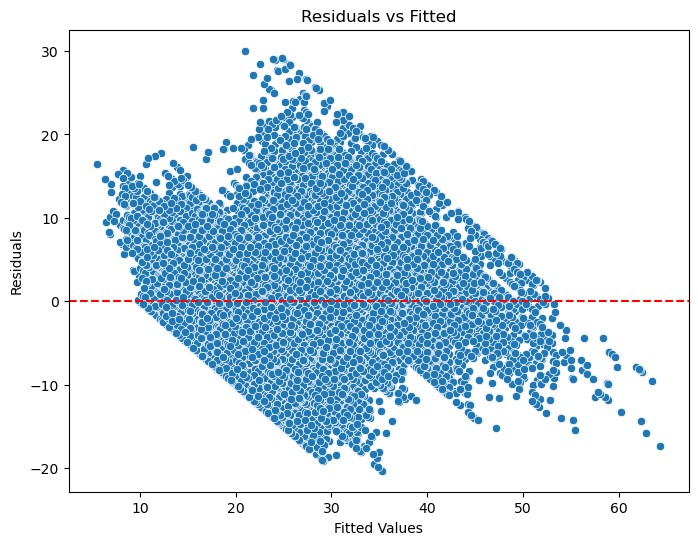

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

## Normality

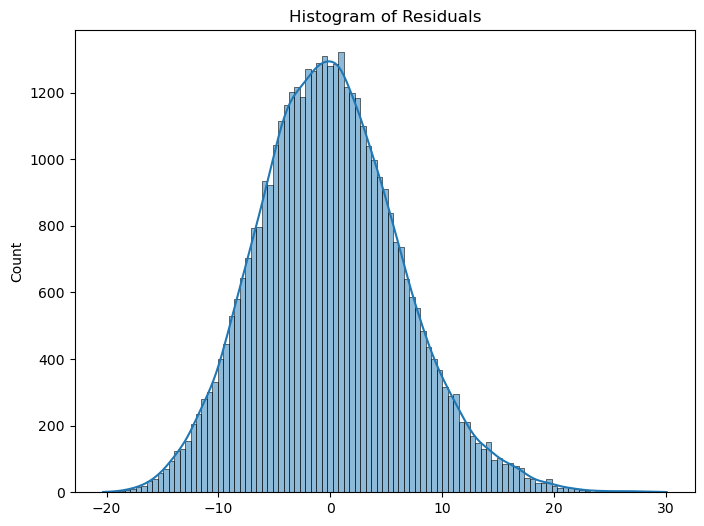

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(model.resid, kde=True)
plt.title("Histogram of Residuals")
plt.show()

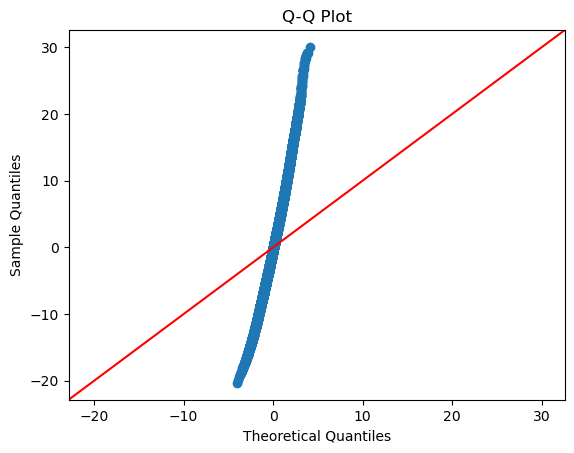

In [22]:


sm.qqplot(model.resid, line='45')
plt.title("Q-Q Plot")
plt.show()

In [23]:


stat, p = shapiro(model.resid)

print("Statistic =", stat)
print("p-value =", p)

Statistic = 0.9949683197112811
p-value = 2.4987863005196474e-34


C:\Users\santr\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 41953.
  res = hypotest_fun_out(*samples, **kwds)


## Homoskedasticity

In [24]:


bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = [
    "Lagrange Multiplier Statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print(dict(zip(labels, bp_test)))

{'Lagrange Multiplier Statistic': np.float64(1375.1467414148249), 'p-value': np.float64(5.831844777682363e-274), 'f-value': np.float64(54.64746980722868), 'f p-value': np.float64(9.028705018001324e-279)}


## Auto-corelation

In [25]:


dw = durbin_watson(model.resid)

print("Durbin-Watson =", dw)

Durbin-Watson = 2.007042509837376


# Ridge and Lasso

In [26]:
y = df['Time_taken(min)']
X = df[['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
        'Type_of_vehicle', 'Festival', 'City', 'Meal_Period', 'Weekend',
        'Delivery_person_Age', 'Delivery_person_Ratings', 'Distance_km', 'Pickup_Wait_Time']]


X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_df, y_train)


lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled_df, y_train)


print("Ridge Coefs (first 5):", ridge_model.coef_[:5].round(4))
print("Lasso Coefs (first 5):", lasso_model.coef_[:5].round(4))

Ridge Coefs (first 5): [ 2.4221 -2.4554  2.2006 -0.0192  0.0578]
Lasso Coefs (first 5): [ 2.3334 -2.382   1.8977 -0.      0.2234]


In [27]:

ridge_preds = ridge_model.predict(X_test_scaled_df)
lasso_preds = lasso_model.predict(X_test_scaled_df)

ridge_r2 = r2_score(y_test, ridge_preds)
lasso_r2 = r2_score(y_test, lasso_preds)


ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))

print("--- Test Performance ---")
print(f"Ridge R-squared: {ridge_r2:.4f} | RMSE: {ridge_rmse:.2f} min")
print(f"Lasso R-squared: {lasso_r2:.4f} | RMSE: {lasso_rmse:.2f} min")

--- Test Performance ---
Ridge R-squared: 0.5240 | RMSE: 6.40 min
Lasso R-squared: 0.5214 | RMSE: 6.42 min
